In [43]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

---


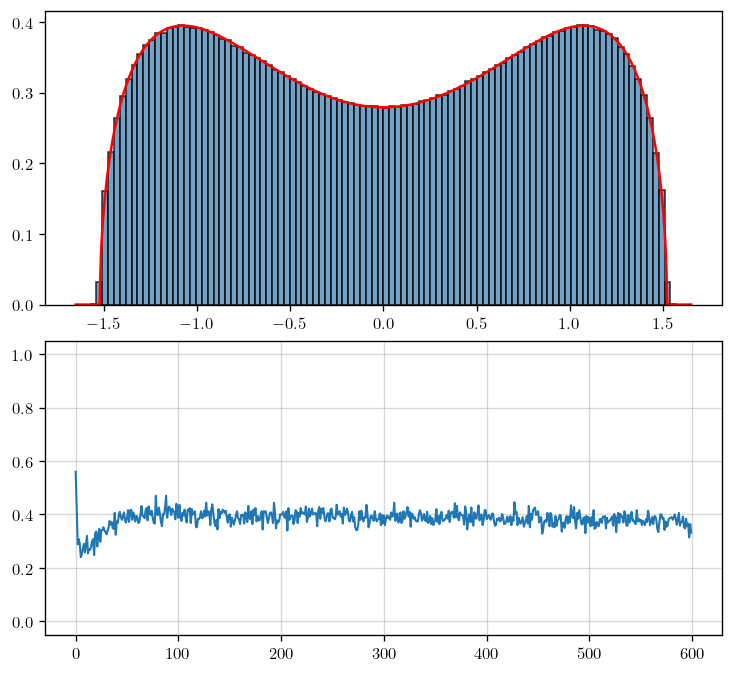

In [49]:
N = 100; beta = 2.0; T = 30.0; M = 500; 
potential_name = "quartic"; num_bins = 100;     
metropolise = True
dt = 0.05

total_steps = int(T/dt); init = random_matrix.init_gue_eigenvalues(M, N)
noise_scale = np.sqrt(2.0*dt/(beta*N))

pipe = simulate.get_pipeline("imla", dt = dt, noise_scale = noise_scale, potential_type = potential_name, beta = beta, metropolise = metropolise)
traj = simulate.simulate_dbm(init, total_steps, pipe)

burn_in = int(8.0/dt) # at T = 8.0.
particles, accepts = simulate.metropolis_experiment(traj, total_steps, burn_in = burn_in, interval = 5)

# Quick plotter.
density_range, limiting_density = densities.get_density(potential_name)

fig, axes = plt.subplots(2, 1, figsize = (6, 5.5))
ax, ax2 = axes 

ax.hist(particles, bins = num_bins, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax.plot(density_range, limiting_density, color = "red", lw = 1.5)
ax.grid(False)

x_range = list(range(len(accepts)))
ax2.plot(x_range, accepts)
ax2.set_ylim(-0.05, 1.05)

plt.show()